In [1]:
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from sklearn import cluster

In [2]:
_path1 = 'C:\\Users\\hp\\Desktop\\3\\5.bmp'
img = cv2.imread(_path1)
print(img.shape)

(600, 600, 3)


In [ ]:
# img2 = cv2.resize(img, (img.shape[1]//4, img.shape[0]//4))
# plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
# data = img2 / 255.0 # use 0...1 scale
# data = data.reshape(-1, 3) # 展开成二维数组

In [4]:
data2 = img / 255.0
data2 = data2.reshape(-1,3)

In [8]:
_kmeans = MiniBatchKMeans(6)
_kmeans.fit(data2) # 对颜色进行聚类
new_colors = _kmeans.cluster_centers_[_kmeans.predict(data2)] # 映射转换原图的颜色

In [9]:
img_recolored = new_colors.reshape(img.shape) # 新的二位颜色数组转为图像矩阵
img_recolored = (img_recolored*255).astype(np.uint8) # 转为8位图像

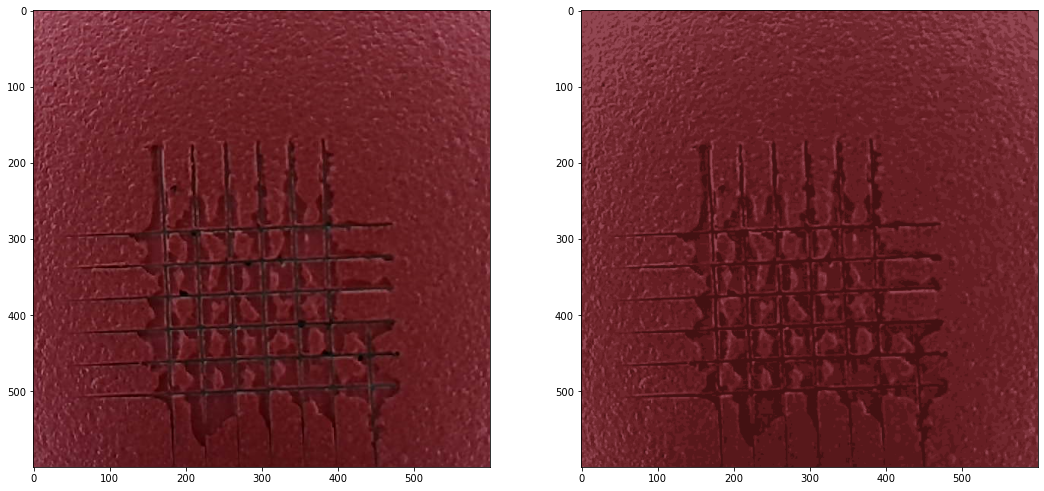

In [10]:
plt.figure(figsize=(18,12))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_recolored, cv2.COLOR_BGR2RGB))

In [15]:
center = _kmeans.cluster_centers_
center = np.expand_dims(center, axis=1)
center = (center*255).astype(np.uint8)
center_gray = cv2.cvtColor(center, cv2.COLOR_BGR2GRAY)
print(center)
print(center_gray)

[[[ 45  39 112]]

 [[ 18  17  67]]

 [[ 27  24  88]]

 [[ 60  51 126]]

 [[ 81  70 146]]

 [[ 35  30 102]]]
[[62]
 [32]
 [43]
 [74]
 [94]
 [52]]


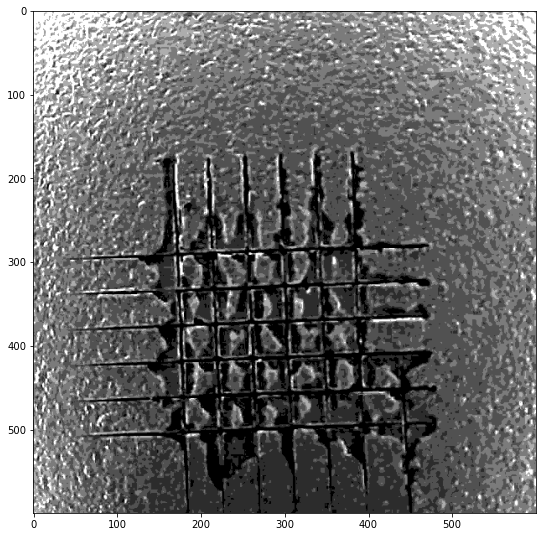

In [11]:
img_recolored_gray = cv2.cvtColor(img_recolored, cv2.COLOR_BGR2GRAY) # 转为灰度图，灰度值的个数为簇的个数
plt.figure(figsize=(9,12))
plt.imshow(img_recolored_gray, cmap='gray')

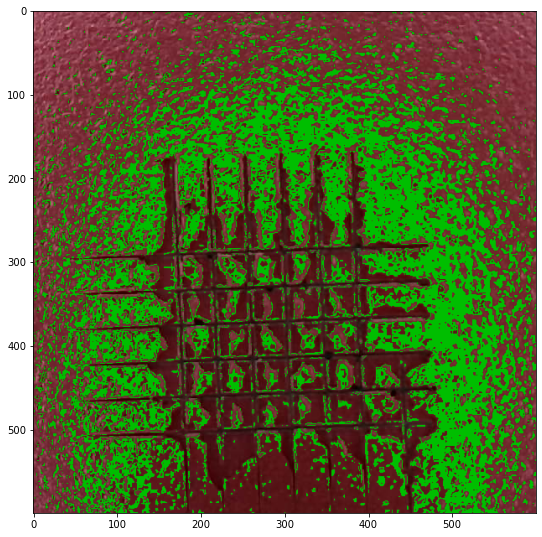

In [21]:
img_copy = img.copy()
img_copy[img_recolored_gray==center_gray[5][0]] = (0,190,0)
plt.figure(figsize=(9,12))
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))